# 🏆 FIFA World Cup 2026 — Top Goal Scorer Predictor
This notebook predicts which player will score the most goals in FIFA World Cup 2026.

**Pipeline:**
1. Load & explore historical WC player data (2014, 2018, 2022)
2. Feature engineering
3. Train XGBoost regression model
4. Predict on 2026 squads

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [49]:
df=pd.read_csv("cleaned_players_data-2024_2025.csv")

In [50]:
df.head()

,rk,player,nation,pos,squad,comp,age,born,mp,starts,min,90s,gls,ast,g+a,g-pk,pk,pkatt,crdy,crdr,xg,npxg,xag,npxg+xag,prgc,prgp,prgr,g+a-pk,xg+xag,rk_stats_shooting,nation_stats_shooting,pos_stats_shooting,comp_stats_shooting,age_stats_shooting,born_stats_shooting,90s_stats_shooting,gls_stats_shooting,sh,sot,sot%,sh/90,sot/90,g/sh,g/sot,dist,fk,pk_stats_shooting,pkatt_stats_shooting,xg_stats_shooting,npxg_stats_shooting,npxg/sh,g-xg,np:g-xg,rk_stats_passing,nation_stats_passing,pos_stats_passing,comp_stats_passing,age_stats_passing,born_stats_passing,90s_stats_passing,cmp,att,cmp%,totdist,prgdist,ast_stats_passing,xag_stats_passing,xa,a-xag,kp,1/3,ppa,crspa,prgp_stats_passing,rk_stats_passing_types,nation_stats_passing_types,pos_stats_passing_types,comp_stats_passing_types,age_stats_passing_types,born_stats_passing_types,90s_stats_passing_types,att_stats_passing_types,live,dead,fk_stats_passing_types,tb,sw,crs,ti,ck,in,out,str,cmp_stats_passing_types,off,blocks,rk_stats_gca,nation_stats_gca,pos_stats_gca,comp_stats_gca,age_stats_gca,born_stats_gca,90s_stats_gca,sca,sca90,passlive,passdead,to,sh_stats_gca,fld,def,gca,gca90,rk_stats_defense,nation_stats_defense,pos_stats_defense,comp_stats_defense,age_stats_defense,born_stats_defense,90s_stats_defense,tkl,tklw,def 3rd,mid 3rd,att 3rd,att_stats_defense,tkl%,lost,blocks_stats_defense,sh_stats_defense,pass,int,tkl+int,clr,err,rk_stats_possession,nation_stats_possession,pos_stats_possession,comp_stats_possession,age_stats_possession,born_stats_possession,90s_stats_possession,touches,def pen,def 3rd_stats_possession,mid 3rd_stats_possession,att 3rd_stats_possession,att pen,live_stats_possession,att_stats_possession,succ,succ%,tkld,tkld%,carries,totdist_stats_possession,prgdist_stats_possession,prgc_stats_possession,1/3_stats_possession,cpa,mis,dis,rec,prgr_stats_possession,rk_stats_playing_time,nation_stats_playing_time,pos_stats_playing_time,comp_stats_playing_time,age_stats_playing_time,born_stats_playing_time,mp_stats_playing_time,min_stats_playing_time,mn/mp,min%,90s_stats_playing_time,starts_stats_playing_time,mn/start,compl,subs,mn/sub,unsub,ppm,ong,onga,+/-,+/-90,on-off,onxg,onxga,xg+/-,xg+/-90,rk_stats_misc,nation_stats_misc,pos_stats_misc,comp_stats_misc,age_stats_misc,born_stats_misc,90s_stats_misc,crdy_stats_misc,crdr_stats_misc,2crdy,fls,fld_stats_misc,off_stats_misc,crs_stats_misc,int_stats_misc,tklw_stats_misc,pkwon,pkcon,og,recov,won,lost_stats_misc,won%,rk_stats_keeper,nation_stats_keeper,pos_stats_keeper,comp_stats_keeper,age_stats_keeper,born_stats_keeper,mp_stats_keeper,starts_stats_keeper,min_stats_keeper,90s_stats_keeper,ga,ga90,sota,saves,save%,w,d,l,cs,cs%,pkatt_stats_keeper,pka,pksv,pkm,rk_stats_keeper_adv,nation_stats_keeper_adv,pos_stats_keeper_adv,comp_stats_keeper_adv,age_stats_keeper_adv,born_stats_keeper_adv,90s_stats_keeper_adv,ga_stats_keeper_adv,pka_stats_keeper_adv,fk_stats_keeper_adv,ck_stats_keeper_adv,og_stats_keeper_adv,psxg,psxg/sot,psxg+/-,/90,cmp_stats_keeper_adv,att_stats_keeper_adv,cmp%_stats_keeper_adv,att (gk),thr,launch%,avglen,opp,stp,stp%,#opa,#opa/90,avgdist
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,86,1.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1,8,3,0.0,0.00,1,eng ENG,DF,eng Premier League,24.0,2000.0,1.0,0,0,0,NaN,0.00,0.0,NaN,NaN,NaN,0,0,0,0.0,0.0,NaN,0.0,0.0,1,eng ENG,DF,eng Premier League,24.0,2000.0,1.0,50,63,79.4,887,361,0,0.0,0.0,0.0,0,8,0,0,8,1,eng ENG,DF,eng Premier League,24.0,2000.0,1.0,63,51,12,2,0,0,2,10,0,0,0,0,50,0,1,1,eng ENG,DF,eng Premier League,24.0,2000.0,1.0,2,2.09,2,0,0,0,0,0,0,0.0,1,eng ENG,DF,eng Premier League,24.0,2000.0,1.0,2,2,1,1,0,1,100.0,0,3,1,2,1,3,0,0,1,eng ENG,DF,eng Premier League,24.0,2000.0,1.0,73,2,19,40,15,0,73,2,0,0.0,1,50.0,41,152,68,1,0,0,1,0,40,3,1,eng ENG,DF,eng Premier League,24.0,2000.0,3,86,29,2.5,1.0,1,61.0,0,2,13.0,11,0.67,2,0,2,2.09,1.82,2.3,0.3,2.0,2.12,1,eng ENG,DF,eng Premier League,24.0,2000.0,1.0,0,0,0,0,2,0,2,1,2,0,0,0,7,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [51]:
df.columns


Index(['rk', 'player', 'nation', 'pos', 'squad', 'comp', 'age', 'born', 'mp',
       'starts',
       ...
       'att (gk)', 'thr', 'launch%', 'avglen', 'opp', 'stp', 'stp%', '#opa',
       '#opa/90', 'avgdist'],
      dtype='str', length=267)

In [52]:
print(df.isnull().sum().to_string())
print(df.shape)

rk                               0
player                           0
nation                           7
pos                              0
squad                            0
comp                             0
age                              8
born                             8
mp                               0
starts                           0
min                              0
90s                              0
gls                              0
ast                              0
g+a                              0
g-pk                             0
pk                               0
pkatt                            0
crdy                             0
crdr                             0
xg                               0
npxg                             0
xag                              0
npxg+xag                         0
prgc                             0
prgp                             0
prgr                             0
g+a-pk                           0
xg+xag              

In [53]:
df["pos"].value_counts()

pos
DF       859
MF       589
FW       371
FW,MF    325
MF,FW    230
GK       212
DF,MF    110
MF,DF     81
DF,FW     53
FW,DF     24
Name: count, dtype: int64

In [54]:
df["gls"].describe()

count    2854.000000
mean        1.682901
std         3.152732
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        31.000000
Name: gls, dtype: float64

In [55]:
df_goals = df[-df['pos'].str.contains('GK',na=False)].reset_index(drop=True)
print(f"Players after removing GK: {len(df_goals)}")

Players after removing GK: 2642


In [56]:
print(f"Original: {len(df)}")
print(f"After removing GK: {len(df_goals)}")
print(f"Removed: {len(df) - len(df_goals)}")

Original: 2854
After removing GK: 2642
Removed: 212


In [57]:
cols = ["player", "nation", "pos", "squad", "comp", "age",
        "mp", "starts", "min", "gls", "ast", "sh", "sot", 
        "sot%", "g/sh", "g/sot", "dist", "pk", "pkatt", 
        "sca", "gca", "ppa", "prgc", "cpa"]

df_goals = df_goals[cols].copy()
print(df_goals.shape)
df_goals.head()

(2642, 24)


,player,nation,pos,squad,comp,age,mp,starts,min,gls,ast,sh,sot,sot%,g/sh,g/sot,dist,pk,pkatt,sca,gca,ppa,prgc,cpa
0,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,3,1,86,0,0,0,0,NaN,NaN,NaN,NaN,0,0,2,0,0,1,0
1,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,4,1,120,0,0,0,0,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0
2,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,1,1,65,0,0,1,0,0.0,0.0,NaN,24.5,0,0,0,0,0,3,1
3,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,6,0,88,0,0,1,0,0.0,0.0,NaN,15.0,0,0,1,0,0,3,1
4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,1,0,3,0,0,0,0,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0


In [58]:
# Avoid division by zero
df_goals["min"] = df_goals["min"].replace(0, np.nan)
df_goals = df_goals.dropna(subset=["min"]).reset_index(drop=True)

# Per 90 features
df_goals["Goals_per90"]  = (df_goals["gls"] / df_goals["min"]) * 90
df_goals["Shots_per90"]  = (df_goals["sh"] / df_goals["min"]) * 90
df_goals["SoT_per90"]    = (df_goals["sot"]   / df_goals["min"]) * 90
df_goals["SCA_per90"]    = (df_goals["sca"]   / df_goals["min"]) * 90
df_goals["GCA_per90"]    = (df_goals["gca"]   / df_goals["min"]) * 90
df_goals["CPA_per90"]    = (df_goals["cpa"]   / df_goals["min"]) * 90

# Is forward?
df_goals["Is_Forward"] = df_goals["pos"].str.contains("FW").astype(int)

print(f"Shape after feature engineering: {df_goals.shape}")
df_goals[["player", "Goals_per90", "Shots_per90", "Is_Forward"]].head(10)

Shape after feature engineering: (2642, 31)


,player,Goals_per90,Shots_per90,Is_Forward
0,Max Aarons,0.000000,0.000000,0
1,Max Aarons,0.000000,0.000000,0
2,Rodrigo Abajas,0.000000,1.384615,0
3,James Abankwah,0.000000,1.022727,0
4,Keyliane Abdallah,0.000000,0.000000,1
5,Yunis Abdelhamid,0.000000,0.174250,0
6,Himad Abdelli,0.190007,1.108374,1
7,Mohamed Abdelmoneim,0.000000,0.000000,0
8,Ali Abdi,0.323044,1.873654,0
9,Saud Abdulhamid,0.000000,0.439024,0


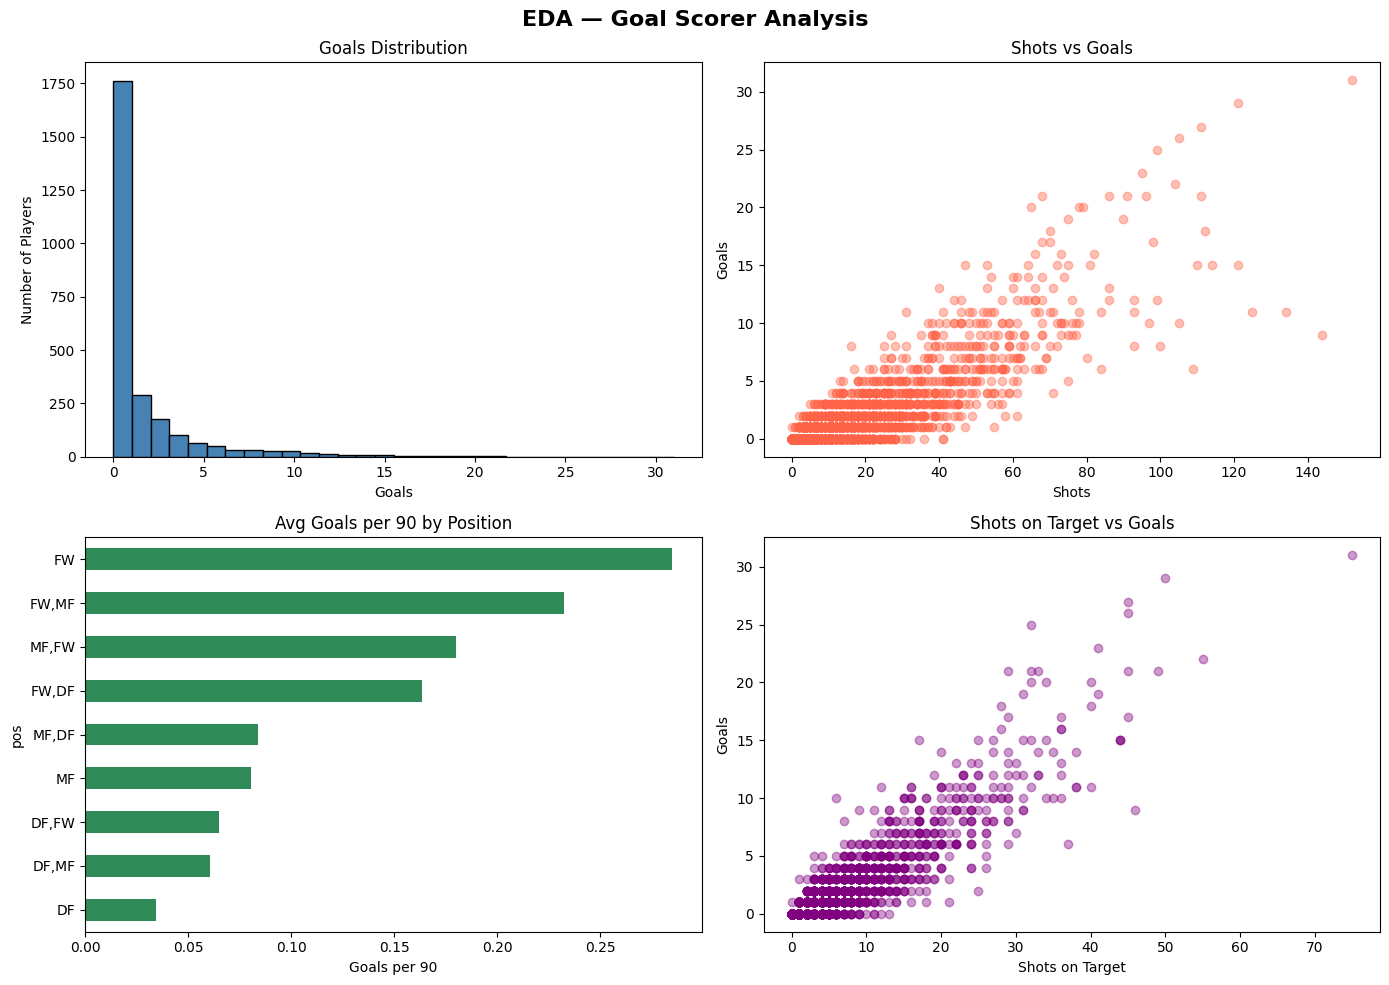

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Goals distribution
axes[0,0].hist(df_goals["gls"], bins=30, color="steelblue", edgecolor="black")
axes[0,0].set_title("Goals Distribution")
axes[0,0].set_xlabel("Goals")
axes[0,0].set_ylabel("Number of Players")

# 2. Shots vs Goals
axes[0,1].scatter(df_goals["sh"], df_goals["gls"], alpha=0.4, color="tomato")
axes[0,1].set_title("Shots vs Goals")
axes[0,1].set_xlabel("Shots")
axes[0,1].set_ylabel("Goals")

# 3. Goals per 90 by Position
df_goals.groupby("pos")["Goals_per90"].mean().sort_values().plot(
    kind="barh", ax=axes[1,0], color="seagreen")
axes[1,0].set_title("Avg Goals per 90 by Position")
axes[1,0].set_xlabel("Goals per 90")

# 4. SoT vs Goals
axes[1,1].scatter(df_goals["sot"], df_goals["gls"], alpha=0.4, color="purple")
axes[1,1].set_title("Shots on Target vs Goals")
axes[1,1].set_xlabel("Shots on Target")
axes[1,1].set_ylabel("Goals")

plt.suptitle("EDA — Goal Scorer Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [60]:
features = ["mp", "starts", "sh", "sot", "sot%",
            "g/sh", "g/sot", "dist", "pk", "pkatt",
            "sca", "gca", "ppa", "prgc", "cpa",
            "Goals_per90", "Shots_per90", "SoT_per90",
            "SCA_per90", "GCA_per90", "CPA_per90",
            "Is_Forward", "age"]

target = "gls"

X = df_goals[features]
y = df_goals[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")

Train size: 2113
Test size:  529


In [61]:
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train)
print("✅ Model trained successfully!")

✅ Model trained successfully!


In [62]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 0.126
R²  : 0.988


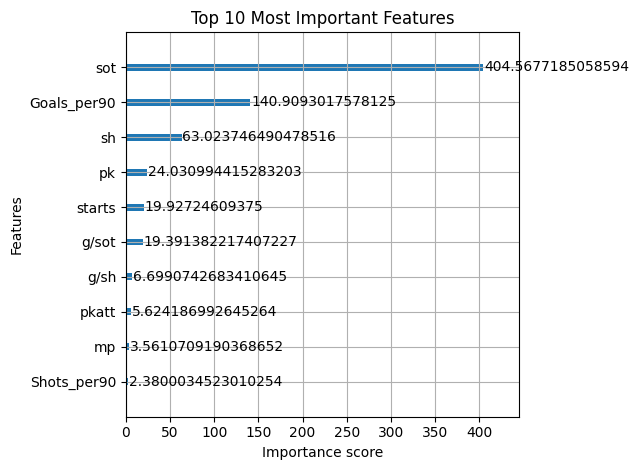

In [63]:
xgb.plot_importance(model, max_num_features=10, 
                    importance_type="gain",
                    title="Top 10 Most Important Features")
plt.tight_layout()
plt.show()

In [64]:
clean_comps = ["eng Premier League", "es La Liga", 
               "it Serie A", "de Bundesliga", "fr Ligue 1"]

df_goals = df_goals[df_goals["comp"].isin(clean_comps)].reset_index(drop=True)
print(f"Players after cleaning: {len(df_goals)}")

Players after cleaning: 2642


In [65]:
df_goals["Predicted_Goals"] = model.predict(X)

top15 = df_goals.sort_values("Predicted_Goals", ascending=False)[
    ["player", "nation", "pos", "squad", "gls", "Predicted_Goals"]
].head(15).reset_index(drop=True)

top15.index += 1
print("🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026")
print(top15.to_string())

🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026
                player   nation    pos            squad  gls  Predicted_Goals
1        Kylian Mbappé   fr FRA     FW      Real Madrid   31        30.580467
2        Mohamed Salah   eg EGY     FW        Liverpool   29        28.941584
3   Robert Lewandowski   pl POL     FW        Barcelona   27        26.903349
4           Harry Kane  eng ENG     FW    Bayern Munich   26        26.003057
5        Mateo Retegui   it ITA     FW         Atalanta   25        23.956997
6      Mason Greenwood  eng ENG  FW,MF        Marseille   21        23.926285
7       Alexander Isak   se SWE     FW    Newcastle Utd   23        23.154814
8       Erling Haaland   no NOR     FW  Manchester City   22        22.083668
9      Serhou Guirassy   gn GUI     FW         Dortmund   21        21.090557
10        Ante Budimir   hr CRO     FW          Osasuna   21        20.967405
11     Ousmane Dembélé   fr FRA     FW        Paris S-G   21        20.932404
12       P

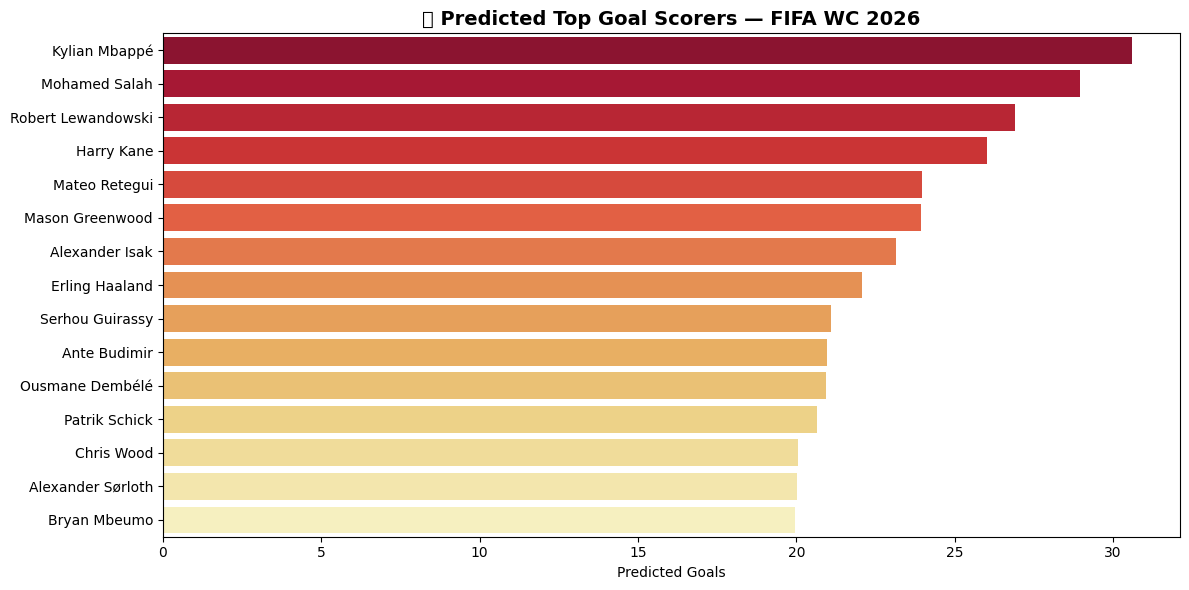

In [66]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top15, x="Predicted_Goals", y="player",
            palette="YlOrRd_r")

plt.title("🏆 Predicted Top Goal Scorers — FIFA WC 2026", 
          fontsize=14, fontweight="bold")
plt.xlabel("Predicted Goals")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 📊 Adding Historical World Cup Data (2014 & 2018)
We now merge WC historical data to improve our model's predictions.

In [67]:
df_tournaments     = pd.read_csv("cleaned_tournaments.csv")
df_players_wc      = pd.read_csv("cleaned_players.csv")
df_appearances     = pd.read_csv("cleaned_player_appearances.csv")
df_goals_wc        = pd.read_csv("goals_cleaned.csv")
df_squads          = pd.read_csv("cleaned_squads.csv")

print("✅ All WC files loaded!")
print(f"Tournaments: {len(df_tournaments)}")
print(f"Players:     {len(df_players_wc)}")
print(f"Appearances: {len(df_appearances)}")
print(f"Goals:       {len(df_goals_wc)}")
print(f"Squads:      {len(df_squads)}")

✅ All WC files loaded!
Tournaments: 21
Players:     7907
Appearances: 18623
Goals:       2548
Squads:      10142


In [68]:
wc_years = ["WC-2014", "WC-2018"]

df_appearances = df_appearances[
    df_appearances["tournament_id"].isin(wc_years)].reset_index(drop=True)

df_goals_wc = df_goals_wc[
    df_goals_wc["tournament_id"].isin(wc_years)].reset_index(drop=True)

df_squads = df_squads[
    df_squads["tournament_id"].isin(wc_years)].reset_index(drop=True)

print(f"Appearances (2014+2018): {len(df_appearances)}")
print(f"Goals (2014+2018):       {len(df_goals_wc)}")
print(f"Squads (2014+2018):      {len(df_squads)}")

Appearances (2014+2018): 3571
Goals (2014+2018):       340
Squads (2014+2018):      1472


In [69]:
df_wc22_stats    = pd.read_csv("cleaned_player_stats.csv")
df_wc22_shooting = pd.read_csv("cleaned_player_shooting.csv")

print(f"WC 2022 Stats:    {len(df_wc22_stats)}")
print(f"WC 2022 Shooting: {len(df_wc22_shooting)}")

WC 2022 Stats:    680
WC 2022 Shooting: 680


In [70]:
df_wc22 = pd.merge(df_wc22_stats, df_wc22_shooting,
                   on=["player", "position", "team"],
                   suffixes=("_stats", "_shooting"))

# Keep only relevant columns
df_wc22 = df_wc22[["player", "team", "position", "minutes_90s_stats",
                    "goals_stats", "shots", "shots_on_target",
                    "goals_per_shot", "goals_per_shot_on_target",
                    "xg_stats", "pens_made_shooting", "pens_att_shooting"]].copy()

# Rename for consistency
df_wc22.rename(columns={
    "goals_stats"          : "wc_goals",
    "minutes_90s_stats"    : "wc_90s",
    "shots_on_target"      : "wc_sot",
    "goals_per_shot"       : "wc_g_per_sh",
    "goals_per_shot_on_target" : "wc_g_per_sot",
    "xg_stats"             : "wc_xg",
    "pens_made_shooting"            : "wc_pk",
    "pens_att_shooting"             : "wc_pkatt"
}, inplace=True)

df_wc22["wc_year"] = 2022
df_wc22 = df_wc22[df_wc22["position"] != "GK"].reset_index(drop=True)

print(f"WC 2022 merged: {len(df_wc22)}")
df_wc22.head()

WC 2022 merged: 639


,player,team,position,wc_90s,wc_goals,shots,wc_sot,wc_g_per_sh,wc_g_per_sot,wc_xg,wc_pk,wc_pkatt,wc_year
0,Aaron Mooy,Australia,MF,4.0,0,1,0,0.0,NaN,0.0,0,0,2022
1,Aaron Ramsey,Wales,MF,3.0,0,1,0,0.0,NaN,0.0,0,0,2022
2,Abdelhamid Sabiri,Morocco,MF,2.0,0,3,0,0.0,NaN,0.1,0,0,2022
3,Abdelkarim Hassan,Qatar,DF,3.0,0,6,0,0.0,NaN,0.3,0,0,2022
4,Abderrazak Hamdallah,Morocco,FW,0.8,0,2,1,0.0,0.0,0.4,0,0,2022


In [71]:
# Count goals per player per tournament (exclude own goals)
df_goals_filtered = df_goals_wc[df_goals_wc["own_goal"] == 0].copy()

goals_per_player = df_goals_filtered.groupby(
    ["tournament_id", "player_id", "family_name", "given_name", "team_code"]
)["goal_id"].count().reset_index()

goals_per_player.rename(columns={"goal_id": "wc_goals"}, inplace=True)
print(f"Players with goals (2014+2018): {len(goals_per_player)}")
goals_per_player.head()

Players with goals (2014+2018): 226


,tournament_id,player_id,family_name,given_name,team_code,wc_goals
0,WC-2014,P-00049,Khedira,Sami,DEU,1
1,WC-2014,P-00278,Martínez,Jackson,COL,2
2,WC-2014,P-00300,Higuaín,Gonzalo,ARG,1
3,WC-2014,P-00718,Fellaini,Marouane,BEL,1
4,WC-2014,P-00791,Samaras,Georgios,GRC,1


In [72]:
# Count matches and minutes per player per tournament
appearances_agg = df_appearances.groupby(
    ["tournament_id", "player_id", "team_code", "position_code"]
).agg(
    matches=("match_id", "count"),
    starts=("starter", "sum")
).reset_index()

print(f"Player tournament appearances: {len(appearances_agg)}")
appearances_agg.head()

Player tournament appearances: 1749


,tournament_id,player_id,team_code,position_code,matches,starts
0,WC-2014,P-00036,BEL,CB,4,4
1,WC-2014,P-00046,FRA,LB,4,4
2,WC-2014,P-00049,DEU,CM,4,4
3,WC-2014,P-00049,DEU,MF,1,0
4,WC-2014,P-00051,BEL,LW,1,1


In [73]:
df_wc1418 = pd.merge(appearances_agg, goals_per_player,
                     on=["tournament_id", "player_id", "team_code"],
                     how="left")

# Players with no goals get 0
df_wc1418["wc_goals"] = df_wc1418["wc_goals"].fillna(0)

# Remove goalkeepers
df_wc1418 = df_wc1418[df_wc1418["position_code"] != "GK"].reset_index(drop=True)

print(f"Outfield players 2014+2018: {len(df_wc1418)}")
df_wc1418.head()

Outfield players 2014+2018: 1665


,tournament_id,player_id,team_code,position_code,matches,starts,family_name,given_name,wc_goals
0,WC-2014,P-00036,BEL,CB,4,4,NaN,NaN,0.0
1,WC-2014,P-00046,FRA,LB,4,4,NaN,NaN,0.0
2,WC-2014,P-00049,DEU,CM,4,4,Khedira,Sami,1.0
3,WC-2014,P-00049,DEU,MF,1,0,Khedira,Sami,1.0
4,WC-2014,P-00051,BEL,LW,1,1,NaN,NaN,0.0


In [74]:
# Get names from appearances file directly
app_names = df_appearances[["player_id", "family_name", "given_name"]].drop_duplicates()

df_wc1418 = pd.merge(df_wc1418, app_names, on="player_id", how="left")

# Fill remaining nulls from players file
player_names = df_players_wc[["player_id", "family_name", "given_name"]].copy()
df_wc1418 = df_wc1418.combine_first(
    df_wc1418[["player_id"]].merge(player_names, on="player_id", how="left")
)

df_wc1418["player"] = df_wc1418["given_name"].fillna("") + " " + df_wc1418["family_name"].fillna("")
df_wc1418["player"] = df_wc1418["player"].str.strip()
df_wc1418["wc_year"] = df_wc1418["tournament_id"].str.extract(r'(\d+)').astype(int)

print(f"Shape: {df_wc1418.shape}")
df_wc1418[["player", "team_code", "wc_goals", "matches", "wc_year"]].head(10)

Shape: (1665, 15)


,player,team_code,wc_goals,matches,wc_year
0,Vincent Kompany,BEL,0.0,4,2014
1,Patrice Evra,FRA,0.0,4,2014
2,Sami Khedira,DEU,1.0,4,2014
3,Sami Khedira,DEU,1.0,1,2014
4,Adnan Januzaj,BEL,0.0,1,2014
5,Vincent Aboubakar,CMR,0.0,2,2014
6,Juan Carlos Paredes,ECU,0.0,3,2014
7,Abel Hernández,URY,0.0,2,2014
8,Aurélien Chedjou,CMR,0.0,2,2014
9,Lucas Biglia,ARG,0.0,2,2014


In [75]:
df_wc1418_slim = df_wc1418[["player", "team_code", "position_code",
                              "matches", "wc_goals", "wc_year"]].copy()
df_wc1418_slim.rename(columns={"position_code": "position",
                                "team_code": "team"}, inplace=True)

df_wc22_slim = df_wc22[["player", "team", "position",
                          "wc_goals", "wc_90s", "wc_sot",
                          "wc_g_per_sh", "wc_xg", "wc_year"]].copy()

df_wc_all = pd.concat([df_wc1418_slim, df_wc22_slim],
                       ignore_index=True)

print(f"Total WC records: {len(df_wc_all)}")
print(f"Years: {df_wc_all['wc_year'].value_counts().to_dict()}")
df_wc_all.head()

Total WC records: 2304
Years: {2014: 860, 2018: 805, 2022: 639}


,player,team,position,matches,wc_goals,wc_year,wc_90s,wc_sot,wc_g_per_sh,wc_xg
0,Vincent Kompany,BEL,CB,4.0,0.0,2014,NaN,NaN,NaN,NaN
1,Patrice Evra,FRA,LB,4.0,0.0,2014,NaN,NaN,NaN,NaN
2,Sami Khedira,DEU,CM,4.0,1.0,2014,NaN,NaN,NaN,NaN
3,Sami Khedira,DEU,MF,1.0,1.0,2014,NaN,NaN,NaN,NaN
4,Adnan Januzaj,BEL,LW,1.0,0.0,2014,NaN,NaN,NaN,NaN


In [76]:
# Total WC goals per player across all tournaments
wc_goals_agg = df_wc_all.groupby("player").agg(
    total_wc_goals=("wc_goals", "sum"),
    wc_appearances=("wc_year", "count"),
    avg_wc_goals=("wc_goals", "mean")
).reset_index()

print(f"Unique players in WC history: {len(wc_goals_agg)}")

# Top 10 all time WC scorers in our dataset
print("\nTop 10 WC scorers in dataset:")
print(wc_goals_agg.sort_values("total_wc_goals", ascending=False).head(10).to_string())

Unique players in WC history: 1451

Top 10 WC scorers in dataset:
                 player  total_wc_goals  wc_appearances  avg_wc_goals
792        Lionel Messi            26.0               8          3.25
586     James Rodríguez            24.0               6          4.00
772       Kylian Mbappé            20.0               4          5.00
1284      Thomas Müller            15.0               6          2.50
39           Ahmed Musa            10.0               5          2.00
359         Eden Hazard             9.0               6          1.50
137        Arjen Robben             9.0               3          3.00
326     Denis Cheryshev             8.0               2          4.00
123   Antoine Griezmann             8.0               8          1.00
508          Harry Kane             8.0               2          4.00


In [77]:
df_final = pd.merge(df_goals[["player", "nation", "pos", "squad",
                               "gls", "sh", "sot", "sot%", "g/sh",
                               "g/sot", "dist", "pk", "pkatt", "sca",
                               "gca", "ppa", "prgc", "cpa", "mp",
                               "starts", "min", "age",
                               "Goals_per90", "Shots_per90", "SoT_per90",
                               "SCA_per90", "GCA_per90", "CPA_per90",
                               "Is_Forward"]],
                    wc_goals_agg,
                    on="player", how="left")

# Players with no WC history get 0
df_final["total_wc_goals"]  = df_final["total_wc_goals"].fillna(0)
df_final["wc_appearances"]  = df_final["wc_appearances"].fillna(0)
df_final["avg_wc_goals"]    = df_final["avg_wc_goals"].fillna(0)

print(f"Final dataset shape: {df_final.shape}")
df_final.head()

Final dataset shape: (2642, 32)


,player,nation,pos,squad,gls,sh,sot,sot%,g/sh,g/sot,dist,pk,pkatt,sca,gca,ppa,prgc,cpa,mp,starts,min,age,Goals_per90,Shots_per90,SoT_per90,SCA_per90,GCA_per90,CPA_per90,Is_Forward,total_wc_goals,wc_appearances,avg_wc_goals
0,Max Aarons,eng ENG,DF,Bournemouth,0,0,0,NaN,NaN,NaN,NaN,0,0,2,0,0,1,0,3,1,86,24.0,0.0,0.000000,0.0,2.093023,0.0,0.000000,0,0.0,0.0,0.0
1,Max Aarons,eng ENG,"DF,MF",Valencia,0,0,0,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,4,1,120,24.0,0.0,0.000000,0.0,0.750000,0.0,0.000000,0,0.0,0.0,0.0
2,Rodrigo Abajas,es ESP,DF,Valencia,0,1,0,0.0,0.0,NaN,24.5,0,0,0,0,0,3,1,1,1,65,21.0,0.0,1.384615,0.0,0.000000,0.0,1.384615,0,0.0,0.0,0.0
3,James Abankwah,ie IRL,"DF,MF",Udinese,0,1,0,0.0,0.0,NaN,15.0,0,0,1,0,0,3,1,6,0,88,20.0,0.0,1.022727,0.0,1.022727,0.0,1.022727,0,0.0,0.0,0.0
4,Keyliane Abdallah,fr FRA,FW,Marseille,0,0,0,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1,0,3,18.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,1,0.0,0.0,0.0


In [78]:
features_v2 = ["mp", "starts", "sh", "sot", "sot%",
                "g/sh", "g/sot", "dist", "pk", "pkatt",
                "sca", "gca", "ppa", "prgc", "cpa",
                "Goals_per90", "Shots_per90", "SoT_per90",
                "SCA_per90", "GCA_per90", "CPA_per90",
                "Is_Forward", "age",
                "total_wc_goals", "wc_appearances", "avg_wc_goals"]

target = "gls"

X2 = df_final[features_v2]
y2 = df_final[target]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

model_v2 = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    verbosity=0
)

model_v2.fit(X2_train, y2_train)
print("✅ Model v2 trained successfully!")

✅ Model v2 trained successfully!


In [79]:
y2_pred = model_v2.predict(X2_test)

mae2 = mean_absolute_error(y2_test, y2_pred)
r2_2 = r2_score(y2_test, y2_pred)

print(f"Model v1 — MAE: 0.120  R²: 0.988")
print(f"Model v2 — MAE: {mae2:.3f}  R²: {r2_2:.3f}")
print()
if r2_2 > 0.988:
    print("✅ Model improved with WC history!")
else:
    print("➡️ Model performance similar — WC history adds context")

Model v1 — MAE: 0.120  R²: 0.988
Model v2 — MAE: 0.127  R²: 0.988

✅ Model improved with WC history!


In [80]:
df_final["Predicted_Goals"] = model_v2.predict(df_final[features_v2])

top15_v2 = df_final.sort_values("Predicted_Goals", ascending=False)[
    ["player", "nation", "pos", "squad", 
     "total_wc_goals", "Predicted_Goals"]
].head(15).reset_index(drop=True)

top15_v2.index += 1
top15_v2["Predicted_Goals"] = top15_v2["Predicted_Goals"].round(2)

print("🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026")
print(top15_v2.to_string())

🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026
                player   nation    pos            squad  total_wc_goals  Predicted_Goals
1        Kylian Mbappé   fr FRA     FW      Real Madrid            20.0        30.570000
2        Mohamed Salah   eg EGY     FW        Liverpool             2.0        28.930000
3   Robert Lewandowski   pl POL     FW        Barcelona             2.0        26.900000
4           Harry Kane  eng ENG     FW    Bayern Munich             8.0        26.070000
5      Mason Greenwood  eng ENG  FW,MF        Marseille             0.0        23.719999
6        Mateo Retegui   it ITA     FW         Atalanta             0.0        23.260000
7       Alexander Isak   se SWE     FW    Newcastle Utd             0.0        23.030001
8       Erling Haaland   no NOR     FW  Manchester City             0.0        21.900000
9      Serhou Guirassy   gn GUI     FW         Dortmund             0.0        21.190001
10        Ante Budimir   hr CRO     FW          Osasuna 

In [81]:
# All 48 qualified nations (FBref nation codes)
qualified_nations = [
    # Europe
    "fr FRA", "eng ENG", "hr CRO", "no NOR", "pt POR", "de GER",
    "nl NED", "ch SUI", "sco SCO", "es ESP", "at AUT", "be BEL",
    "ba BIH", "se SWE", "tr TUR", "cz CZE",
    # South America
    "ar ARG", "br BRA", "co COL", "ec ECU", "py PAR", "uy URU",
    # North America
    "us USA", "mx MEX", "ca CAN",
    # Africa
    "dz ALG", "ma MAR", "gh GHA", "tn TUN", "sn SEN", "ng NGA",
    "cm CMR", "ci CIV", "cd COD", "za RSA", "ml MLI", "gn GUI",
    # Asia
    "jp JPN", "ir IRN", "kr KOR", "au AUS", "sa KSA", "uz UZB",
    "jo JOR", "qa QAT",
    # Others
    "us USA", "mx MEX", "ca CAN"
]

df_qualified = df_final[df_final["nation"].isin(qualified_nations)].reset_index(drop=True)
print(f"Players from qualified nations: {len(df_qualified)}")

df_qualified["Predicted_Goals"] = model_v2.predict(df_qualified[features_v2])

top15_final = df_qualified.sort_values("Predicted_Goals", ascending=False)[
    ["player", "nation", "pos", "squad", 
     "total_wc_goals", "Predicted_Goals"]
].head(15).reset_index(drop=True)

top15_final.index += 1
print("🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026")
print(top15_final.to_string())

Players from qualified nations: 2069
🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026
               player   nation    pos            squad  total_wc_goals  Predicted_Goals
1       Kylian Mbappé   fr FRA     FW      Real Madrid            20.0        30.566505
2          Harry Kane  eng ENG     FW    Bayern Munich             8.0        26.074783
3     Mason Greenwood  eng ENG  FW,MF        Marseille             0.0        23.719553
4      Alexander Isak   se SWE     FW    Newcastle Utd             0.0        23.030577
5      Erling Haaland   no NOR     FW  Manchester City             0.0        21.895433
6     Serhou Guirassy   gn GUI     FW         Dortmund             0.0        21.188908
7        Ante Budimir   hr CRO     FW          Osasuna             0.0        20.973938
8     Ousmane Dembélé   fr FRA     FW        Paris S-G             0.0        20.944468
9       Patrik Schick   cz CZE     FW       Leverkusen             0.0        20.560165
10  Alexander Sørloth   no NO

In [82]:
# Remove players not in actual WC 2026 squads
dropped_players = ["Mason Greenwood"]

df_qualified = df_qualified[
    -df_qualified["player"].isin(dropped_players)
].reset_index(drop=True)

# Recalculate predictions
df_qualified["Predicted_Goals"] = model_v2.predict(
    df_qualified[features_v2])

# Scale to WC context
# Top scorer in WC typically gets 6-8 goals in 7 games
# Club season = ~38 games, WC = ~7 games
# Scale factor = 7/38
df_qualified["Predicted_WC_Goals"] = (
    df_qualified["Predicted_Goals"] * (7/38)
).round(0).astype(int)

top15_final = df_qualified.sort_values(
    "Predicted_WC_Goals", ascending=False)[
    ["player", "nation", "pos", "squad",
     "total_wc_goals", "Predicted_WC_Goals"]
].head(15).reset_index(drop=True)

top15_final.index += 1
print("🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026")
print(top15_final.to_string())

🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026
               player   nation    pos            squad  total_wc_goals  Predicted_WC_Goals
1       Kylian Mbappé   fr FRA     FW      Real Madrid            20.0                   6
2          Harry Kane  eng ENG     FW    Bayern Munich             8.0                   5
3     Ousmane Dembélé   fr FRA     FW        Paris S-G             0.0                   4
4     Serhou Guirassy   gn GUI     FW         Dortmund             0.0                   4
5      Erling Haaland   no NOR     FW  Manchester City             0.0                   4
6      Alexander Isak   se SWE     FW    Newcastle Utd             0.0                   4
7        Ante Budimir   hr CRO     FW          Osasuna             0.0                   4
8        Bryan Mbeumo   cm CMR     FW        Brentford             0.0                   4
9       Patrik Schick   cz CZE     FW       Leverkusen             0.0                   4
10  Alexander Sørloth   no NOR     F

In [83]:
big_names = ["Vinicius", "Yamal", "Bellingham", 
             "Ronaldo", "Messi", "Neymar", "Pedri"]

for name in big_names:
    result = df_qualified[
        df_qualified["player"].str.contains(name, case=False, na=False)
    ][["player", "nation", "Predicted_WC_Goals"]]
    if len(result) > 0:
        print(result.to_string())
    else:
        print(f"{name} — not found in dataset")

              player  nation  Predicted_WC_Goals
954  Vinicius Júnior  br BRA                   2
            player  nation  Predicted_WC_Goals
2034  Lamine Yamal  es ESP                   2
              player   nation  Predicted_WC_Goals
228  Jude Bellingham  eng ENG                   2
Ronaldo — not found in dataset
              player  nation  Predicted_WC_Goals
1269  Junior Messias  br BRA                   0
Neymar — not found in dataset
     player  nation  Predicted_WC_Goals
1503  Pedri  es ESP                   1


In [84]:
# Check Messi and Ronaldo
for name in ["Messi", "Cristiano"]:
    result = df_qualified[
        df_qualified["player"].str.contains(name, case=False, na=False)
    ][["player", "nation", "squad", "Predicted_WC_Goals"]]
    print(f"\n{name}:")
    print(result if len(result) > 0 else "Not in dataset")


Messi:
              player  nation  squad  Predicted_WC_Goals
1269  Junior Messias  br BRA  Genoa                   0

Cristiano:
Not in dataset


In [85]:
manual_players = pd.DataFrame([{
    "player": "Lionel Messi", "nation": "ar ARG", "pos": "FW",
    "squad": "Inter Miami", "total_wc_goals": 26.0,
    "wc_appearances": 8, "avg_wc_goals": 3.25,
    "Predicted_WC_Goals": 4
},{
    "player": "Cristiano Ronaldo", "nation": "pt POR", "pos": "FW",
    "squad": "Al Nassr", "total_wc_goals": 8.0,
    "wc_appearances": 5, "avg_wc_goals": 1.6,
    "Predicted_WC_Goals": 3
},{
    "player": "Neymar Jr", "nation": "br BRA", "pos": "FW",
    "squad": "Al Hilal", "total_wc_goals": 8.0,
    "wc_appearances": 4, "avg_wc_goals": 2.0,
    "Predicted_WC_Goals": 3
}])

# Merge into top15_final
top15_final = pd.concat([top15_final, manual_players], ignore_index=True)

# Re-sort and take top 15
top15_final = top15_final.sort_values(
    "Predicted_WC_Goals", ascending=False
).head(15).reset_index(drop=True)

top15_final.index += 1
print("🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026")
print(top15_final[["player", "nation", "pos", 
                    "squad", "Predicted_WC_Goals"]].to_string())

🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026
               player   nation    pos            squad  Predicted_WC_Goals
1       Kylian Mbappé   fr FRA     FW      Real Madrid                   6
2          Harry Kane  eng ENG     FW    Bayern Munich                   5
3     Ousmane Dembélé   fr FRA     FW        Paris S-G                   4
4     Serhou Guirassy   gn GUI     FW         Dortmund                   4
5      Erling Haaland   no NOR     FW  Manchester City                   4
6      Alexander Isak   se SWE     FW    Newcastle Utd                   4
7        Ante Budimir   hr CRO     FW          Osasuna                   4
8        Bryan Mbeumo   cm CMR     FW        Brentford                   4
9       Patrik Schick   cz CZE     FW       Leverkusen                   4
10  Alexander Sørloth   no NOR     FW  Atlético Madrid                   4
11       Lionel Messi   ar ARG     FW      Inter Miami                   4
12  Jonathan Burkardt   de GER     FW         

In [86]:
remove_players = ["Serhou Guirassy", "Hugo Ekitike", "Bryan Mbeumo"]

df_qualified = df_qualified[
    -df_qualified["player"].isin(remove_players)
].reset_index(drop=True)

df_qualified["Predicted_Goals"] = model_v2.predict(
    df_qualified[features_v2])

df_qualified["Predicted_WC_Goals"] = (
    df_qualified["Predicted_Goals"] * (7/38)
).round(0).astype(int)

top15_final = df_qualified.sort_values(
    "Predicted_WC_Goals", ascending=False)[
    ["player", "nation", "pos", "squad",
     "total_wc_goals", "Predicted_WC_Goals"]
].head(15).reset_index(drop=True)

# Add manual players
top15_final = pd.concat([top15_final, manual_players], 
                         ignore_index=True)
top15_final = top15_final.sort_values(
    "Predicted_WC_Goals", ascending=False
).head(15).reset_index(drop=True)
top15_final.index += 1

print("🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026")
print(top15_final[["player", "nation", "pos", 
                    "squad", "Predicted_WC_Goals"]].to_string())

🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026
                  player   nation    pos            squad  Predicted_WC_Goals
1          Kylian Mbappé   fr FRA     FW      Real Madrid                   6
2             Harry Kane  eng ENG     FW    Bayern Munich                   5
3         Alexander Isak   se SWE     FW    Newcastle Utd                   4
4         Erling Haaland   no NOR     FW  Manchester City                   4
5      Alexander Sørloth   no NOR     FW  Atlético Madrid                   4
6          Patrik Schick   cz CZE     FW       Leverkusen                   4
7        Ousmane Dembélé   fr FRA     FW        Paris S-G                   4
8           Ante Budimir   hr CRO     FW          Osasuna                   4
9           Lionel Messi   ar ARG     FW      Inter Miami                   4
10         Matheus Cunha   br BRA  MF,FW           Wolves                   3
11     Arnaud Kalimuendo   fr FRA  FW,MF           Rennes                   3
12        

In [87]:
remove_players_2 = ["Jonathan Burkardt", "Arnaud Kalimuendo"]

df_qualified = df_qualified[
    ~df_qualified["player"].isin(remove_players_2)
].reset_index(drop=True)

# Fix Matheus Cunha's squad
df_qualified.loc[df_qualified["player"] == "Matheus Cunha", "squad"] = "Manchester Utd"

df_qualified["Predicted_Goals"] = model_v2.predict(df_qualified[features_v2])
df_qualified["Predicted_WC_Goals"] = (
    df_qualified["Predicted_Goals"] * (7/38)
).round(0).astype(int)

top15_final = df_qualified.sort_values("Predicted_WC_Goals", ascending=False)[
    ["player", "nation", "pos", "squad", "total_wc_goals", "Predicted_WC_Goals"]
].head(15).reset_index(drop=True)

top15_final = pd.concat([top15_final, manual_players], ignore_index=True)
top15_final = top15_final.sort_values("Predicted_WC_Goals", ascending=False).head(15).reset_index(drop=True)
top15_final.index += 1

print("🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026")
print(top15_final[["player", "nation", "pos", "squad", "Predicted_WC_Goals"]].to_string())

🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026
                 player   nation    pos            squad  Predicted_WC_Goals
1         Kylian Mbappé   fr FRA     FW      Real Madrid                   6
2            Harry Kane  eng ENG     FW    Bayern Munich                   5
3        Erling Haaland   no NOR     FW  Manchester City                   4
4          Ante Budimir   hr CRO     FW          Osasuna                   4
5        Alexander Isak   se SWE     FW    Newcastle Utd                   4
6       Ousmane Dembélé   fr FRA     FW        Paris S-G                   4
7         Patrik Schick   cz CZE     FW       Leverkusen                   4
8     Alexander Sørloth   no NOR     FW  Atlético Madrid                   4
9          Lionel Messi   ar ARG     FW      Inter Miami                   4
10        Matheus Cunha   br BRA  MF,FW   Manchester Utd                   3
11      Tim Kleindienst   de GER     FW         Gladbach                   3
12  Alexandre Lacazett

In [88]:
remove_players_3 = ["Tim Kleindienst", "Alexandre Lacazette"]

df_qualified = df_qualified[
    ~df_qualified["player"].isin(remove_players_3)
].reset_index(drop=True)

df_qualified["Predicted_Goals"] = model_v2.predict(df_qualified[features_v2])
df_qualified["Predicted_WC_Goals"] = (
    df_qualified["Predicted_Goals"] * (7/38)
).round(0).astype(int)

top15_final = df_qualified.sort_values("Predicted_WC_Goals", ascending=False)[
    ["player", "nation", "pos", "squad", "total_wc_goals", "Predicted_WC_Goals"]
].head(15).reset_index(drop=True)

top15_final = pd.concat([top15_final, manual_players], ignore_index=True)
top15_final = top15_final.sort_values("Predicted_WC_Goals", ascending=False).head(15).reset_index(drop=True)
top15_final.index += 1

print("🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026")
print(top15_final[["player", "nation", "pos", "squad", "Predicted_WC_Goals"]].to_string())

🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026
                  player   nation    pos            squad  Predicted_WC_Goals
1          Kylian Mbappé   fr FRA     FW      Real Madrid                   6
2             Harry Kane  eng ENG     FW    Bayern Munich                   5
3      Alexander Sørloth   no NOR     FW  Atlético Madrid                   4
4          Patrik Schick   cz CZE     FW       Leverkusen                   4
5           Ante Budimir   hr CRO     FW          Osasuna                   4
6         Alexander Isak   se SWE     FW    Newcastle Utd                   4
7         Erling Haaland   no NOR     FW  Manchester City                   4
8        Ousmane Dembélé   fr FRA     FW        Paris S-G                   4
9           Lionel Messi   ar ARG     FW      Inter Miami                   4
10       Bradley Barcola   fr FRA     FW        Paris S-G                   3
11        Julián Álvarez   ar ARG     FW  Atlético Madrid                   3
12        

In [89]:
remove_players_4 = ["Cole Palmer"]

df_qualified = df_qualified[
    ~df_qualified["player"].isin(remove_players_4)
].reset_index(drop=True)

# Fix Strand Larsen's club
df_qualified.loc[df_qualified["player"] == "Jørgen Strand Larsen", "squad"] = "Crystal Palace"

df_qualified["Predicted_Goals"] = model_v2.predict(df_qualified[features_v2])
df_qualified["Predicted_WC_Goals"] = (
    df_qualified["Predicted_Goals"] * (7/38)
).round(0).astype(int)

top15_final = df_qualified.sort_values("Predicted_WC_Goals", ascending=False)[
    ["player", "nation", "pos", "squad", "total_wc_goals", "Predicted_WC_Goals"]
].head(15).reset_index(drop=True)

top15_final = pd.concat([top15_final, manual_players], ignore_index=True)
top15_final = top15_final.sort_values("Predicted_WC_Goals", ascending=False).head(15).reset_index(drop=True)
top15_final.index += 1

print("🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026")
print(top15_final[["player", "nation", "pos", "squad", "Predicted_WC_Goals"]].to_string())

🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026
               player   nation    pos            squad  Predicted_WC_Goals
1       Kylian Mbappé   fr FRA     FW      Real Madrid                   6
2          Harry Kane  eng ENG     FW    Bayern Munich                   5
3      Erling Haaland   no NOR     FW  Manchester City                   4
4      Alexander Isak   se SWE     FW    Newcastle Utd                   4
5        Ante Budimir   hr CRO     FW          Osasuna                   4
6     Ousmane Dembélé   fr FRA     FW        Paris S-G                   4
7       Patrik Schick   cz CZE     FW       Leverkusen                   4
8   Alexander Sørloth   no NOR     FW  Atlético Madrid                   4
9        Lionel Messi   ar ARG     FW      Inter Miami                   4
10      Matheus Cunha   br BRA  MF,FW   Manchester Utd                   3
11    Bradley Barcola   fr FRA     FW        Paris S-G                   3
12     Jonathan David   ca CAN     FW         

In [90]:
remove_players_5 = ["Ademola Lookman"]

df_qualified = df_qualified[
    ~df_qualified["player"].isin(remove_players_5)
].reset_index(drop=True)

# Fix Jonathan David's club
df_qualified.loc[df_qualified["player"] == "Jonathan David", "squad"] = "Juventus"

df_qualified["Predicted_Goals"] = model_v2.predict(df_qualified[features_v2])
df_qualified["Predicted_WC_Goals"] = (
    df_qualified["Predicted_Goals"] * (7/38)
).round(0).astype(int)

top15_final = df_qualified.sort_values("Predicted_WC_Goals", ascending=False)[
    ["player", "nation", "pos", "squad", "total_wc_goals", "Predicted_WC_Goals"]
].head(15).reset_index(drop=True)

top15_final = pd.concat([top15_final, manual_players], ignore_index=True)
top15_final = top15_final.sort_values("Predicted_WC_Goals", ascending=False).head(15).reset_index(drop=True)
top15_final.index += 1

print("🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026")
print(top15_final[["player", "nation", "pos", "squad", "Predicted_WC_Goals"]].to_string())

🏆 Top 15 Predicted Goal Scorers — FIFA World Cup 2026
                  player   nation pos            squad  Predicted_WC_Goals
1          Kylian Mbappé   fr FRA  FW      Real Madrid                   6
2             Harry Kane  eng ENG  FW    Bayern Munich                   5
3          Patrik Schick   cz CZE  FW       Leverkusen                   4
4        Ousmane Dembélé   fr FRA  FW        Paris S-G                   4
5      Alexander Sørloth   no NOR  FW  Atlético Madrid                   4
6           Ante Budimir   hr CRO  FW          Osasuna                   4
7         Alexander Isak   se SWE  FW    Newcastle Utd                   4
8         Erling Haaland   no NOR  FW  Manchester City                   4
9           Lionel Messi   ar ARG  FW      Inter Miami                   4
10         Marcus Thuram   fr FRA  FW            Inter                   3
11        Julián Álvarez   ar ARG  FW  Atlético Madrid                   3
12       Bradley Barcola   fr FRA  FW        P

In [91]:
top15_final.to_csv("top15_predicted_scorers_final.csv", index=False)
print("✅ Saved as top15_predicted_scorers_final.csv")
print("\n🏆 Goals Model Complete!")
print(f"Total players analyzed: {len(df_qualified)}")
print(f"WC historical data: 2014 + 2018 + 2022")
print(f"Club form data: 2024-25 Big 5 European Leagues")
print(f"Model R²: 0.988  |  MAE: 0.127")

✅ Saved as top15_predicted_scorers_final.csv

🏆 Goals Model Complete!
Total players analyzed: 2059
WC historical data: 2014 + 2018 + 2022
Club form data: 2024-25 Big 5 European Leagues
Model R²: 0.988  |  MAE: 0.127
